In [1]:
%load_ext autoreload
%autoreload 2

# Import the library
import greenlearning as gl
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

Using TensorFlow 2 backend.

Instructions for updating:
non-resource variables are not supported in the long term


In [ ]:
np.random.seed(42)

N_train = 75
noise_ratio_arr = np.linspace(0, 0.5, 50)[1:] # Avoid noise_ratio = 0 as we've already done that
print(noise_ratio_arr)
resample = 1
repeats = range(5)

for i in repeats:
    for noise_ratio in noise_ratio_arr:

        # Construct neural networks for G and homogeneous solution
        G_network = gl.matrix_networks([2] + [50] * 4 + [1], "rational", (1,1))
        U_hom_network = gl.matrix_networks([1] + [50] * 4 + [1], "rational", (1,))

        # Define the model
        model = gl.Model(G_network, U_hom_network, N_train=N_train, noise_ratio=noise_ratio, resample=resample, repeat=i, adam_steps=10, lbfgs_steps=10)

        # Train the model on the dataset "helmholtz" in the path "examples/datasets/"
        model.train("examples/datasets/","helmholtz")

        # Save the NNs evaluated at a grid in a csv file
        model.save_results()

        # Close the TensorFlow session
        model.sess.close()

It: 0, Loss = 1.201e+00
INFO:tensorflow:Optimization terminated with:
  Message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT
  Objective function value: 0.978047
  Number of iterations: 10
  Number of functions evaluations: 13
G_pred shape (100, 100)


In [ ]:
def relative_L2_error(y_true, y_pred, eps=1e-12):
    """
    Uniform-grid discrete relative L2 error, expressed as a %, averaged over examples on axis=0.
    y_true, y_pred shape: (B, ...grid axes...)
    """
    # reduce over all non-batch axes → per-example norms
    reduce_axes = tuple(range(1, y_true.ndim))
    num = np.sqrt(np.sum((y_pred - y_true)**2, axis=reduce_axes))
    den = np.sqrt(np.sum(y_true**2,          axis=reduce_axes))
    rel = num / (den + eps)          # shape (B,)
    return 100 * np.mean(rel)             # scalar

path = f'examples/datasets/helmholtz.mat'
raw_data = sp.io.loadmat(path)

N_test = 20

# N_train_arr = np.array([1, 5, 10, 15, 20, 25, 30])
N_train = 75
noise_ratio_arr = np.linspace(0, 0.5, 50)
resample = 1
repeats = 5

u = raw_data['F'][::2 * resample, -N_test:] # (100, N_test)
print('u.shape', u.shape)
v = raw_data['U'][::resample, -N_test:] # (100, N_test)
print('v.shape', v.shape)

domain_u = raw_data['X'][::resample, 0] # (100,)
print('domain_u.shape', domain_u.shape)
print('domain_u', domain_u)

df = pd.DataFrame(columns=['N_train', 'noise_ratio', 'resample', 'repeat', 'relative_L2_error'])

for i in range(repeats):
    for noise_ratio in noise_ratio_arr:
        
        G_est = np.genfromtxt('results_csv/Green_helmholtz_rational_0_Ntrain%d_noiseratio%.6f_resample%d_repeat%d.csv' % (N_train, noise_ratio, resample, i), delimiter=',')

        # plt.figure()
        # plt.imshow(G_est, extent=(domain_u.min(), domain_u.max(), domain_u.min(), domain_u.max()))
        # plt.colorbar()
        # plt.title('Estimated Green\'s function')
        # plt.show()

        integrand = G_est[:, :, None] * u[None, :, :]  # (100, 100, N_test)  # broadcast u over columns (y-axis)
        v_est = np.trapz(integrand, x=domain_u, axis=1) # (100, N_test)  # integrate over y (axis=1)

        # test_idx = 0
        # fig, axs = plt.subplots(1, 2, figsize=(10, 5))
        # axs[0].plot(domain_u, u[:, test_idx], label='$u$ (source term)')
        # # axs[0].set_title('u')
        # axs[0].legend()
        # axs[1].plot(domain_u, v[:, test_idx], label='$v$ true')
        # axs[1].plot(domain_u, v_est[:, test_idx], '--', label='$v$ pred')
        # # axs[1].set_title('v')
        # axs[1].legend()
        # plt.show()

        vT = v.T
        v_estT = v_est.T

        error = relative_L2_error(vT, v_estT)

        print(f'noise_ratio: {noise_ratio}, repeat: {i}, relative L2 error: {error:f}%')
        df = pd.concat((df, pd.DataFrame({'N_train': [N_train], 'noise_ratio': [noise_ratio], 'resample': [resample], 'repeat': [i], 'relative_L2_error': [error]})), ignore_index=True)

df.to_csv('results/error_vs_noise_ratio.csv', index=False)

u.shape (100, 20)
v.shape (100, 20)
domain_u.shape (100,)
domain_u [0.         0.01010101 0.02020202 0.03030303 0.04040404 0.05050505
 0.06060606 0.07070707 0.08080808 0.09090909 0.1010101  0.11111111
 0.12121212 0.13131313 0.14141414 0.15151515 0.16161616 0.17171717
 0.18181818 0.19191919 0.2020202  0.21212121 0.22222222 0.23232323
 0.24242424 0.25252525 0.26262626 0.27272727 0.28282828 0.29292929
 0.3030303  0.31313131 0.32323232 0.33333333 0.34343434 0.35353535
 0.36363636 0.37373737 0.38383838 0.39393939 0.4040404  0.41414141
 0.42424242 0.43434343 0.44444444 0.45454545 0.46464646 0.47474747
 0.48484848 0.49494949 0.50505051 0.51515152 0.52525253 0.53535354
 0.54545455 0.55555556 0.56565657 0.57575758 0.58585859 0.5959596
 0.60606061 0.61616162 0.62626263 0.63636364 0.64646465 0.65656566
 0.66666667 0.67676768 0.68686869 0.6969697  0.70707071 0.71717172
 0.72727273 0.73737374 0.74747475 0.75757576 0.76767677 0.77777778
 0.78787879 0.7979798  0.80808081 0.81818182 0.82828283 0.83838

/tmp/ipykernel_1150915/1312664607.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  v_est = np.trapz(integrand, x=domain_u, axis=1) # (100, N_test)  # integrate over y (axis=1)
/tmp/ipykernel_1150915/1312664607.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat((df, pd.DataFrame({'N_train': [N_train], 'noise_ratio': [noise_ratio], 'resample': [resample], 'repeat': [i], 'relative_L2_error': [error]})), ignore_index=True)


noise_ratio: 0.0, repeat: 0, relative L2 error: 7.851428%
noise_ratio: 0.01020408163265306, repeat: 0, relative L2 error: 7.866890%
noise_ratio: 0.02040816326530612, repeat: 0, relative L2 error: 7.916952%
noise_ratio: 0.030612244897959183, repeat: 0, relative L2 error: 8.106990%
noise_ratio: 0.04081632653061224, repeat: 0, relative L2 error: 7.967301%
noise_ratio: 0.0510204081632653, repeat: 0, relative L2 error: 8.536840%
noise_ratio: 0.061224489795918366, repeat: 0, relative L2 error: 8.415445%
noise_ratio: 0.07142857142857142, repeat: 0, relative L2 error: 8.540223%
noise_ratio: 0.08163265306122448, repeat: 0, relative L2 error: 8.380106%
noise_ratio: 0.09183673469387754, repeat: 0, relative L2 error: 8.445094%
noise_ratio: 0.1020408163265306, repeat: 0, relative L2 error: 9.251093%
noise_ratio: 0.11224489795918366, repeat: 0, relative L2 error: 8.850488%
noise_ratio: 0.12244897959183673, repeat: 0, relative L2 error: 9.226931%
noise_ratio: 0.13265306122448978, repeat: 0, relative 

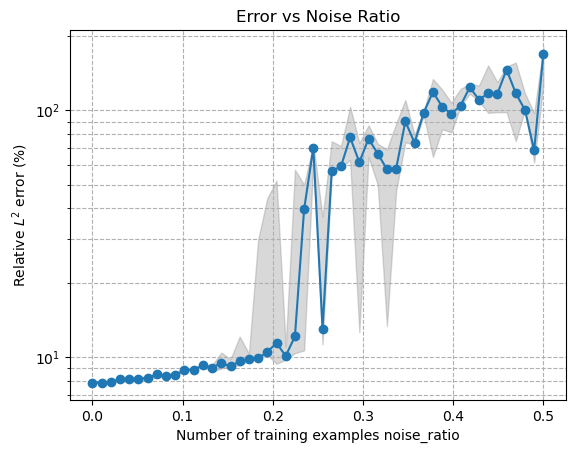

In [13]:
data = pd.read_csv('error_vs_noise_ratio.csv')

# group by N_train and compute mean and std of relative_L2_error
grouped = data.groupby('noise_ratio')['relative_L2_error'].agg(median='median', q25=lambda x: np.percentile(x, 25), q75=lambda x: np.percentile(x, 75)).reset_index()

plt.figure()
plt.plot(grouped['noise_ratio'], grouped['median'], 'o-', label='median')
plt.fill_between(grouped['noise_ratio'], grouped['q25'], grouped['q75'], color='gray', alpha=0.3, label='IQR')
# plt.errorbar(grouped['noise_ratio'], grouped['median'], yerr=[grouped['q25'], grouped['q75']], fmt='o-', capsize=5, linestyle='None', label='IQR')
plt.yscale('log')
plt.xlabel('Number of training examples noise_ratio')
plt.ylabel('Relative $L^2$ error (%)')
plt.title('Error vs Noise Ratio')
plt.grid(True, which="both", ls="--")
# plt.savefig('error_vs_noise_ratio.png', dpi=300)
plt.show()